In [1]:
import numpy as np

# ---- Input and target ----
x = np.array([1.0, 2.0])         # Shape (2,)
y_true = np.array([1, 0])        # One-hot true label

# ---- Initialize weights and biases ----
W1 = np.array([[0.1, 0.2],       # Shape (2, 2)
               [0.3, 0.4]])
b1 = np.array([0.0, 0.0])

W2 = np.array([[0.1, 0.2],       # Shape (2, 2)
               [0.3, 0.4]])
b2 = np.array([0.0, 0.0])

# ---- ReLU function and its derivative ----
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# ---- Softmax function ----
def softmax(z):
    exps = np.exp(z - np.max(z))  # for numerical stability
    return exps / np.sum(exps)

# ---- Forward pass ----
print("----------")
print("x:", x)
print("W1:", W1)
z1 = np.dot(x, W1) + b1          # Input → Hidden
print("z1:", z1)

a1 = relu(z1)
print("a1:", a1)
print("----------")

print("W2:", W2)
z2 = np.dot(a1, W2) + b2         # Hidden → Output
print("z2:", z2)

y_pred = softmax(z2)
print("y_pred:", y_pred)
print("----------")

# ---- Cross-entropy loss ----
loss = -np.sum(y_true * np.log(y_pred + 1e-9))  # Avoid log(0)
print("Loss:", loss)

# ---- Backpropagation ----
print("----------")
# Output layer gradient
dL_dz2 = y_pred - y_true                   # Shape (2,)
print("dL_dz2:", dL_dz2)

print("----------")
# Gradients for W2 and b2
dL_dW2 = np.outer(a1, dL_dz2)              # Shape (2, 2)
dL_db2 = dL_dz2
print("dL_dW2:", dL_dW2)
print("dL_db2:", dL_db2)
print("----------")

# Backprop to hidden layer
dL_da1 = np.dot(W2, dL_dz2)                # Shape (2,)
dL_dz1 = dL_da1 * relu_derivative(z1)      # Apply ReLU'

# Gradients for W1 and b1
dL_dW1 = np.outer(x, dL_dz1)               # Shape (2, 2)
dL_db1 = dL_dz1

# ---- Weight update ----
lr = 0.1
W1 -= lr * dL_dW1
b1 -= lr * dL_db1
W2 -= lr * dL_dW2
b2 -= lr * dL_db2

# ---- Print updated weights ----
print("Updated W1:\n", W1)
print("Updated b1:", b1)
print("Updated W2:\n", W2)
print("Updated b2:", b2)

#This goes on repeat until ypred and actual converge

----------
x: [1. 2.]
W1: [[0.1 0.2]
 [0.3 0.4]]
z1: [0.7 1. ]
a1: [0.7 1. ]
----------
W2: [[0.1 0.2]
 [0.3 0.4]]
z2: [0.37 0.54]
y_pred: [0.45760206 0.54239794]
----------
Loss: 0.781755336685318
----------
dL_dz2: [-0.54239794  0.54239794]
----------
dL_dW2: [[-0.37967856  0.37967856]
 [-0.54239794  0.54239794]]
dL_db2: [-0.54239794  0.54239794]
----------
Updated W1:
 [[0.09457602 0.19457602]
 [0.28915204 0.38915204]]
Updated b1: [-0.00542398 -0.00542398]
Updated W2:
 [[0.13796786 0.16203214]
 [0.35423979 0.34576021]]
Updated b2: [ 0.05423979 -0.05423979]


### Approach:
1. Forward Pass:
You compute the output of your network by applying weights to the inputs, passing them through activation functions (like sigmoid or ReLU), and getting your predictions.

2. Loss Function:
Once you have the predictions, you calculate the error or loss (e.g., using cross-entropy). This tells you how wrong the model's prediction is.

3. Backward Pass (Backpropagation):
Gradient of the Loss w.r.t. Output: This is how much the loss will change with respect to the output of the network.

Gradient of the Loss w.r.t. Weights: Using the chain rule, we backpropagate the error through the layers to compute how much each weight contributed to the error.

4. Update Weights:
Using the gradients calculated in step 3, you update the weights in the direction that reduces the loss (this is typically done using Gradient Descent).

### Backward Pass (Backpropagation)

Now we compute gradients of the loss with respect to weights, and update them.

#### Step 1: dL/dz2 (Gradient of loss w.r.t. softmax input)

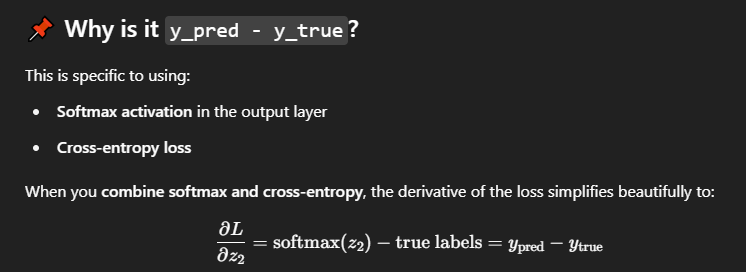
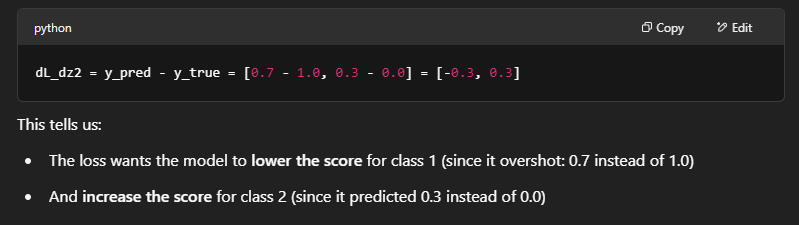
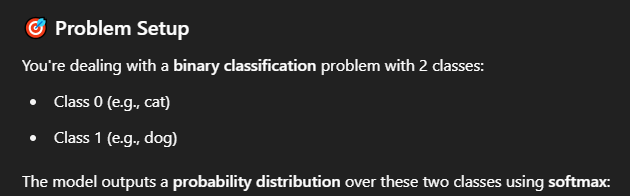
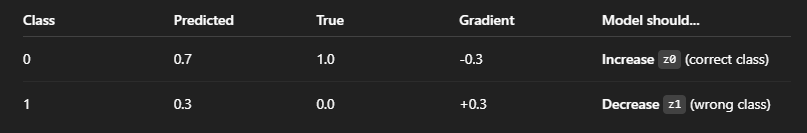
*Increase Z2[0] and decrease Z2[1]

In the context of neural networks, a gradient refers to the rate of change of the loss function with respect to the network's parameters (weights and biases). It essentially tells us how much the loss function will change if we adjust the parameters by a small amount. This information is crucial for updating the parameters during the training process to minimize the loss. 
Here's a more detailed explanation:
#### Loss Function:
The loss function quantifies the difference between the network's predictions and the actual labels, providing a measure of how well the network is performing. 
#### Gradients:

Gradients are the derivatives of the loss function with respect to each parameter (weight and bias). They indicate the direction and magnitude of the change needed to minimize the loss. 
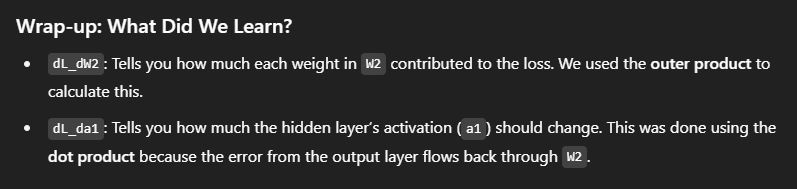